# Bonus — turning a sad face into a smiley face with PCA

**Chapter VI of the *Unsupervised Learning / Dimensionality Reduction* project.**

> *Using the face expression recognition dataset, fit the dimensionality reduction model
> to compress faces. Using the representations, try to turn a sad face into a smiley face
> and vice versa.*

**The plan.** The task has two halves, and the second one is only possible because of a
property of the first.

1. **Compress.** Every 48×48 grayscale face is a point in $\mathbb{R}^{2304}$. Faces do
   not fill that space — they live near a much thinner subspace, because every face has
   two eyes above a nose above a mouth. We fit a **PCA** on the training faces and keep
   $K$ directions, so each face becomes a vector $z \in \mathbb{R}^{K}$: this is the
   "dimensionality reduction model to compress faces".
2. **Edit.** Emotion is not a coordinate of that latent space, but it turns out to be a
   *direction* in it. We estimate the **smile direction** as the difference of the two
   class means,

   $$ d \;=\; \frac{1}{|H|}\sum_{i \in H} z_i \;-\; \frac{1}{|S|}\sum_{i \in S} z_i ,
      \qquad H = \text{happy},\ S = \text{sad},$$

   and then *walk along it*: $z' = z + \alpha\,d$. Decoding $z'$ back to pixels gives the
   same person with a different expression. This is the classic **latent-space attribute
   arithmetic** demonstration, the eigenface analogue of `king - man + woman = queen`.

**Why PCA and not UMAP / t-SNE.** This is the whole reason the approach works and it is
worth stating up front. Editing requires a **decoder**: we must be able to take the
modified vector $z'$ and turn it back into an image. PCA is a *linear, invertible* map,

$$ z = W (x - \mu), \qquad \hat{x} = W^{\mathsf T} z + \mu, \qquad W \in \mathbb{R}^{K \times 2304},$$

so `pca.inverse_transform` is an exact formula and any point of the latent space —
including one we invented by adding $\alpha d$ — decodes to a picture. t-SNE and UMAP
are *embeddings*: they learn coordinates for the training points and optimise a
neighbourhood-preservation loss, not a reconstruction loss. `umap.inverse_transform`
exists but is an extra learned approximation, and t-SNE has no inverse at all. Neither
gives the guarantee we need, so PCA (equivalently, a truncated SVD of the centred face
matrix) is the right tool here. NMF is invertible too and is compared in section 8.

**Data.** `data/fer2013.npz` — FER-2013, the dataset behind the Kaggle "face expression
recognition dataset" the task links to. 35 887 images, 48×48, grayscale, 7 emotion
classes, with the original competition split (28 709 train / 7 178 validation).
See `data/SOURCES.md` for how it was obtained and verified.

In [1]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF, PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Minimal chart style: recessive axes/grid, colors assigned in fixed order.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "font.size": 10, "figure.dpi": 100,
})

pd.set_option("display.max_columns", 40)
NB_START = time.perf_counter()

H_PX = W_PX = 48          # every FER-2013 image is 48 x 48
N_PIXELS = H_PX * W_PX    # = 2304 raw features


def timed(build):
    """Run ``build()`` and return ``(result, elapsed seconds)``."""
    start = time.perf_counter()
    result = build()
    return result, time.perf_counter() - start


def show_face(ax, vec, title=None, vmin=0.0, vmax=1.0):
    """Draw one flattened face on ``ax`` with a fixed [0, 1] intensity scale."""
    ax.imshow(np.asarray(vec).reshape(H_PX, W_PX), cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")
    if title is not None:
        ax.set_title(title, fontsize=7.5, pad=3)


def show_signed(ax, vec, title=None):
    """Draw a signed pixel pattern (eigenface, difference image) on a diverging map."""
    img = np.asarray(vec).reshape(H_PX, W_PX)
    lim = float(np.abs(img).max())
    ax.imshow(img, cmap="coolwarm", vmin=-lim, vmax=lim)
    ax.axis("off")
    if title is not None:
        ax.set_title(title, fontsize=7.5, pad=3)


print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


## 1. The faces

`fer2013.npz` is an array archive rather than a folder of PNGs — same images, far faster
to load. We inspect the keys before assuming anything about them, and in particular we
read the **label→index mapping out of the file** (`label_names`) instead of hard-coding
`happy = 3`.

In [2]:
archive = np.load("data/fer2013.npz", allow_pickle=True)
print("keys:", list(archive.keys()))
for key in archive:
    arr = archive[key]
    print(f"  {key:12s} shape={str(arr.shape):16s} dtype={arr.dtype}")

X_img = archive["X"]                      # (35887, 48, 48) uint8
y = archive["y"].astype(np.int64)
split = archive["split"]
label_names = [str(s) for s in archive["label_names"]]

# Read the mapping out of the file rather than assuming the canonical order.
LABEL_TO_ID = {name: i for i, name in enumerate(label_names)}
HAPPY, SAD = LABEL_TO_ID["happy"], LABEL_TO_ID["sad"]
print("\nlabel -> index:", LABEL_TO_ID)
print(f"HAPPY = {HAPPY}, SAD = {SAD}")

keys: ['X', 'y', 'split', 'usage', 'label_names']


  X            shape=(35887, 48, 48)  dtype=uint8
  y            shape=(35887,)         dtype=int8
  split        shape=(35887,)         dtype=<U10
  usage        shape=(35887,)         dtype=<U12
  label_names  shape=(7,)             dtype=<U8



label -> index: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'sad': 4, 'surprise': 5, 'neutral': 6}
HAPPY = 3, SAD = 4


In [3]:
counts = pd.DataFrame({
    "emotion": label_names,
    "total": [int((y == i).sum()) for i in range(len(label_names))],
    "train": [int(((y == i) & (split == "train")).sum()) for i in range(len(label_names))],
    "validation": [int(((y == i) & (split == "validation")).sum()) for i in range(len(label_names))],
}).set_index("emotion")
counts["share"] = (counts["total"] / len(y)).round(4)
print(f"{len(y)} images, split: {dict(zip(*np.unique(split, return_counts=True)))}")
print(f"intensity range: {X_img.min()}..{X_img.max()} ({X_img.dtype})")
counts

35887 images, split: {np.str_('train'): np.int64(28709), np.str_('validation'): np.int64(7178)}
intensity range: 0..255 (uint8)


,total,train,validation,share
emotion,,,,
angry,4953,3995,958,0.1380
disgust,547,436,111,0.0152
fear,5121,4097,1024,0.1427
happy,8989,7215,1774,0.2505
sad,6077,4830,1247,0.1693
surprise,4002,3171,831,0.1115
neutral,6198,4965,1233,0.1727


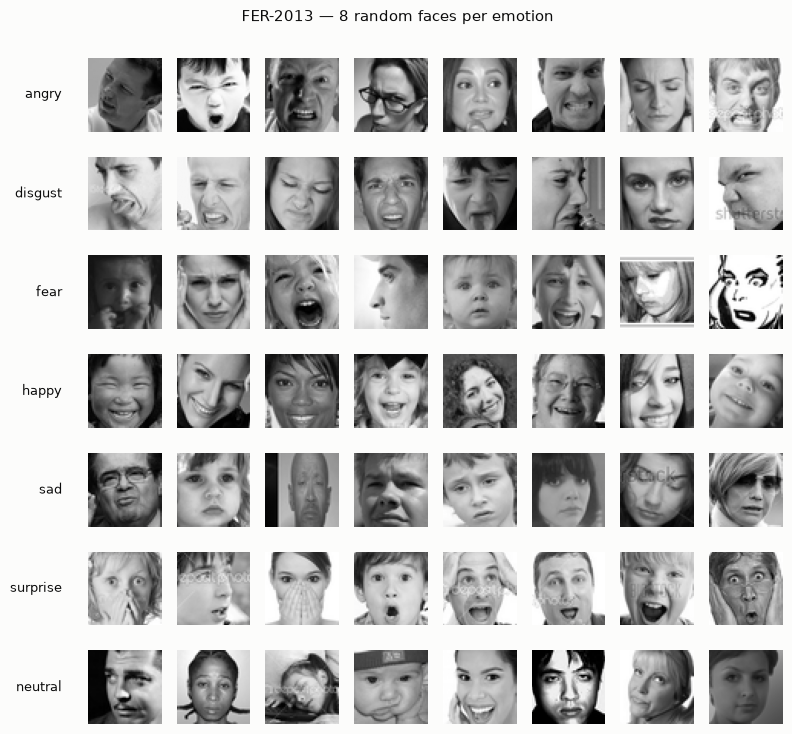

In [4]:
fig, axes = plt.subplots(len(label_names), 8, figsize=(8.0, 7.4))
for row, name in enumerate(label_names):
    pool = np.flatnonzero(y == LABEL_TO_ID[name])
    for col, idx in enumerate(rng.choice(pool, 8, replace=False)):
        axes[row, col].imshow(X_img[idx], cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")
    axes[row, 0].text(-0.35, 0.5, name, transform=axes[row, 0].transAxes,
                      ha="right", va="center", fontsize=9, color=INK)
fig.suptitle("FER-2013 — 8 random faces per emotion", fontsize=11, y=0.995)
plt.tight_layout()
plt.show()

**What we are working with.** These are *not* the clean, aligned portraits of the classic
eigenfaces papers (Yale, ORL, LFW-aligned). FER-2013 was scraped with a face detector, so
the crops are inconsistent: heads are tilted and rotated, some faces are in profile, some
are partly occluded by hands or glasses, illumination ranges from blown-out to nearly
black, and there are drawings and cartoons among the photographs — several images even
carry a visible stock-photo watermark, which is a reminder of how they were collected.
The labels are
crowd-sourced and noisy — human agreement on FER-2013 is only about 65 % — and section 7
turns up a handful of images that are not faces at all yet still carry an emotion label.

That matters for what follows and we will come back to it: everything the model learns is
a mixture of *expression* and of whatever else varies between the classes.

**The two classes we need** are `happy` (8 989 images) and `sad` (6 077). `happy` is the
largest class in the dataset and `sad` the third largest, so the class means we are about
to compute are estimated from thousands of faces each — comfortably enough for the
difference between them to be stable.

### Vectorising and splitting

Each image is flattened to a 2304-vector and scaled to $[0, 1]$ (a plain division by 255 —
a monotone rescaling that leaves the geometry of the data untouched but keeps the PCA
eigenvalues in a readable range). We deliberately **do not** standardise per pixel:
subtracting the mean is PCA's own job (`pca.mean_`), and dividing each pixel by its own
standard deviation would amplify the noisy image border relative to the informative
centre of the face.

We keep the **original FER-2013 split**. The validation fold is never used to fit the PCA,
to compute the smile direction, or to train the probe classifiers of section 5 — it only
supplies the faces we morph and the faces we score. That is what makes the evaluation in
section 5 non-circular.

In [5]:
X = X_img.reshape(len(X_img), N_PIXELS).astype(np.float32) / 255.0

is_train = split == "train"
is_valid = split == "validation"
X_train, y_train = X[is_train], y[is_train]
X_valid, y_valid = X[is_valid], y[is_valid]

print(f"X          {X.shape}  {X.dtype}  range {X.min():.3f}..{X.max():.3f}")
print(f"X_train    {X_train.shape}")
print(f"X_valid    {X_valid.shape}")
print(f"\nmemory: {X.nbytes / 2**20:.0f} MiB")

X          (35887, 2304)  float32  range 0.000..1.000
X_train    (28709, 2304)
X_valid    (7178, 2304)

memory: 315 MiB


## 2. Fitting the compressor — PCA on 28 709 faces

PCA on a face matrix is the **eigenfaces** method (Sirovich & Kirby 1987, Turk & Pentland
1991). It centres the data at the mean face $\mu$ and finds the orthonormal directions
$w_1, w_2, \dots$ of maximal remaining variance; those directions, reshaped back to
48×48, are pictures in their own right.

We use `svd_solver="covariance_eigh"`, which is the right solver for this shape: with
$n = 28\,709 \gg p = 2304$ it is cheaper to form the $2304 \times 2304$ covariance matrix
once and diagonalise it than to run an SVD of the tall data matrix. It also returns the
**complete** spectrum — all 2304 eigenvalues — which is what the explained-variance curve
below needs.

In [6]:
pca_full, fit_seconds = timed(
    lambda: PCA(svd_solver="covariance_eigh", random_state=RANDOM_STATE).fit(X_train)
)
print(f"PCA fitted on {X_train.shape[0]} faces in {fit_seconds:.1f}s")
print(f"components: {pca_full.n_components_}  (= min(n_samples, n_features))")
print(f"mean_ shape {pca_full.mean_.shape}, components_ shape {pca_full.components_.shape}")

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
print(f"\nPC1 alone explains {evr[0]:.1%} of the pixel variance;"
      f" the first 10 explain {cum_evr[9]:.1%}")

PCA fitted on 28709 faces in 9.2s
components: 2304  (= min(n_samples, n_features))
mean_ shape (2304,), components_ shape (2304, 2304)

PC1 alone explains 28.9% of the pixel variance; the first 10 explain 66.7%


In [7]:
thresholds = pd.DataFrame({
    "variance kept": [f"{t:.0%}" for t in (0.80, 0.90, 0.95, 0.99)],
    "components needed": [int(np.searchsorted(cum_evr, t)) + 1 for t in (0.80, 0.90, 0.95, 0.99)],
})
thresholds["compression 2304/k"] = (N_PIXELS / thresholds["components needed"]).round(1)
thresholds

,variance kept,components needed,compression 2304/k
0,80%,32,72.0
1,90%,103,22.4
2,95%,253,9.1
3,99%,880,2.6


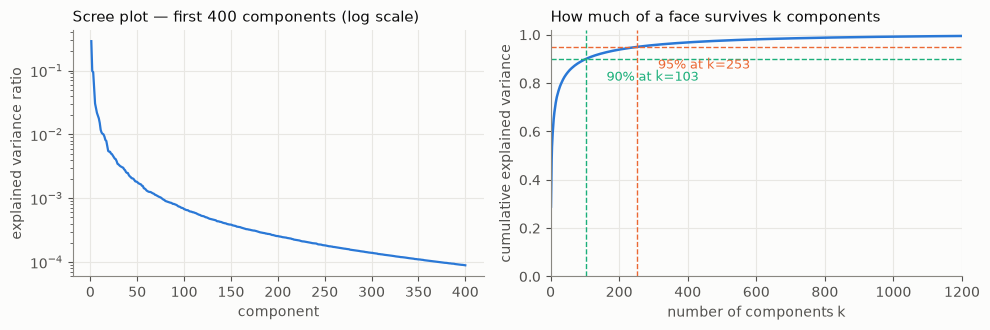

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

ax1.plot(np.arange(1, 401), evr[:400], color=C_BLUE, lw=1.6)
ax1.set_yscale("log")
ax1.set_xlabel("component")
ax1.set_ylabel("explained variance ratio")
ax1.set_title("Scree plot — first 400 components (log scale)", loc="left", fontsize=11)

ax2.plot(np.arange(1, len(cum_evr) + 1), cum_evr, color=C_BLUE, lw=1.8)
for level, color in [(0.90, C_AQUA), (0.95, C_ORANGE)]:
    k = int(np.searchsorted(cum_evr, level)) + 1
    ax2.axhline(level, color=color, lw=1, ls="--")
    ax2.axvline(k, color=color, lw=1, ls="--")
    ax2.annotate(f"{level:.0%} at k={k}", (k, level), xytext=(k + 60, level - 0.09),
                 fontsize=9, color=color)
ax2.set_xlim(0, 1200)
ax2.set_ylim(0, 1.02)
ax2.set_xlabel("number of components k")
ax2.set_ylabel("cumulative explained variance")
ax2.set_title("How much of a face survives k components", loc="left", fontsize=11)

plt.tight_layout()
plt.show()

### Choosing $K$

The curve has no elbow — face data never does, because there is a long tail of
high-frequency detail that keeps contributing a little. So the choice is a trade-off, and
the numbers above frame it: 103 components already carry 90 % of the pixel variance,
253 carry 95 %, and 880 are needed for 99 %.

We take **$K = 200$**:

* it keeps **93.9 %** of the training variance and compresses each face **11.5×**
  (2304 numbers → 200);
* the reconstruction panel below shows that going from 200 to 400 components buys detail
  that is barely visible at 48×48;
* and — the reason that matters most here — the direction we are about to estimate is a
  *difference of two noisy sample means*. Every extra component adds one more coordinate
  of estimation noise to $d$ while contributing less and less signal. Keeping the latent
  space tight is a form of regularisation for the edit, not just for the compression.

Rather than re-fitting, we **truncate** the fitted model. Truncating a fitted PCA is
exactly `PCA(n_components=K)` on the same data: the eigenvectors of the covariance matrix
do not change when you decide to keep fewer of them, so the first $K$ rows of
`components_` are already the answer. The assertion in the next cell checks that the
truncated estimator's `transform` / `inverse_transform` agree with the explicit matrix
formulas.

In [9]:
def truncate_pca(fitted, k):
    """Copy of a fitted PCA keeping only its first ``k`` components.

    Equivalent to ``PCA(n_components=k)`` fitted on the same data: the eigenvectors of
    the covariance matrix are unchanged by how many of them we choose to keep.
    """
    out = copy.deepcopy(fitted)
    out.components_ = fitted.components_[:k].copy()
    out.explained_variance_ = fitted.explained_variance_[:k].copy()
    out.explained_variance_ratio_ = fitted.explained_variance_ratio_[:k].copy()
    out.singular_values_ = fitted.singular_values_[:k].copy()
    out.noise_variance_ = float(fitted.explained_variance_[k:].mean())
    out.n_components = k
    out.n_components_ = k
    return out


K = 200
pca = truncate_pca(pca_full, K)

# sanity: the estimator really is the linear encoder/decoder written in the intro
probe = X_valid[:5]
assert np.allclose(pca.transform(probe),
                   (probe - pca.mean_) @ pca.components_.T, atol=1e-4)
assert np.allclose(pca.inverse_transform(pca.transform(probe)),
                   pca.transform(probe) @ pca.components_ + pca.mean_, atol=1e-4)

print(f"K = {K} components")
print(f"variance kept (train): {pca.explained_variance_ratio_.sum():.4f}")
print(f"compression: {N_PIXELS} -> {K} floats per face  ({N_PIXELS / K:.1f}x)")
print("encoder / decoder identities asserted")

K = 200 components
variance kept (train): 0.9387
compression: 2304 -> 200 floats per face  (11.5x)
encoder / decoder identities asserted


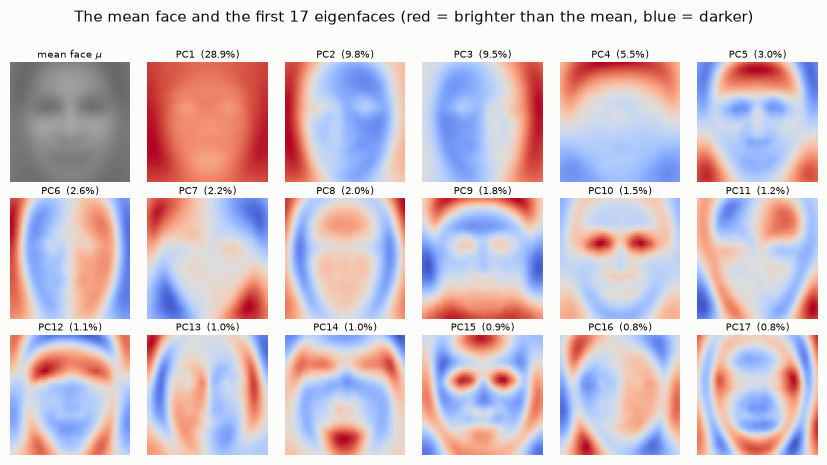

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(8.4, 4.6))
show_face(axes[0, 0], pca.mean_, "mean face $\\mu$")
axes[0, 0].axis("off")
for j in range(1, 6):
    show_signed(axes[0, j], pca.components_[j - 1],
                f"PC{j}  ({evr[j - 1]:.1%})")
for i in range(1, 3):
    for j in range(6):
        c = 5 + (i - 1) * 6 + j
        show_signed(axes[i, j], pca.components_[c], f"PC{c + 1}  ({evr[c]:.1%})")
fig.suptitle("The mean face and the first 17 eigenfaces "
             "(red = brighter than the mean, blue = darker)", fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

**Reading the eigenfaces.** They are not faces of people, they are *edit directions*: a
face is written as the mean face plus a weighted sum of them, so a positive coefficient
brightens the red regions and darkens the blue ones.

* **PC1 (28.9 % on its own)** is almost uniform over the whole frame. It is the global
  brightness / exposure of the crop — we confirm this quantitatively in section 6, where
  its score correlates **0.994** with the mean intensity of the image. That a *lighting*
  artefact is the single largest source of variance is a symptom of an uncontrolled
  dataset, and it will come back to bite us when we interpret the smile direction.
* **PC2 and PC3** (9.8 % and 9.5 %) are centre-versus-border contrasts: how large the head
  is inside the crop. **PC4 and PC5** add top-bottom and edge illumination gradients.
  All of these are geometry and lighting *of the photograph*, not of the face — which is
  the price of an unregistered dataset.
* From roughly **PC8–PC10** onwards actual facial structure appears: paired dark blobs at
  the eye sockets (clearest in PC10 and PC15), a vertical nose ridge, and — crucially for
  this task — a horizontal band across the mouth (PC12, PC14). These are the components an
  expression can move; section 3 shows that the smile direction does load on several of
  them, alongside the leading global ones.
* By PC15+ the patterns are getting high-frequency; past a few hundred they are
  essentially texture noise. This is the visual version of the argument for keeping $K$
  modest.

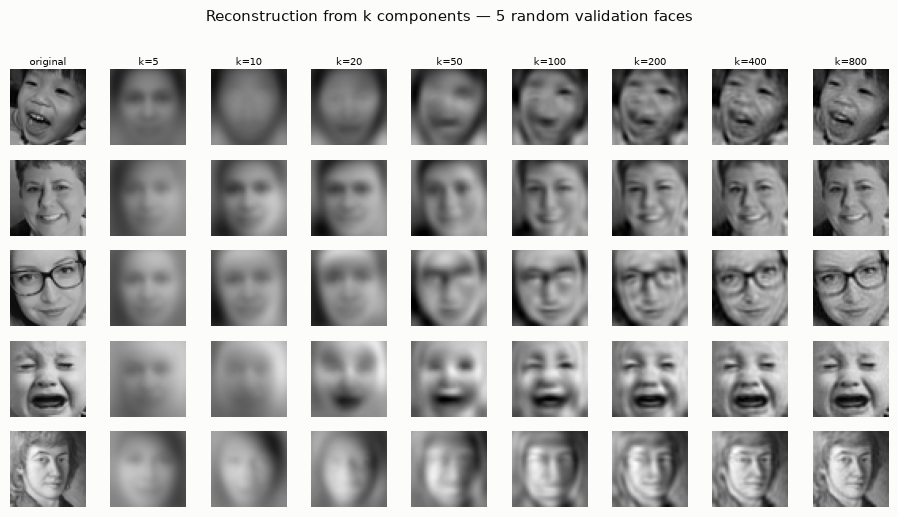

In [11]:
ladder = [5, 10, 20, 50, 100, 200, 400, 800]
faces_idx = rng.choice(len(X_valid), 5, replace=False)

fig, axes = plt.subplots(len(faces_idx), len(ladder) + 1,
                         figsize=(1.02 * (len(ladder) + 1), 1.02 * len(faces_idx)))
for row, idx in enumerate(faces_idx):
    show_face(axes[row, 0], X_valid[idx], "original" if row == 0 else None)
    for col, k in enumerate(ladder):
        model_k = truncate_pca(pca_full, k)
        show_face(axes[row, col + 1],
                  model_k.inverse_transform(model_k.transform(X_valid[idx][None]))[0].clip(0, 1),
                  f"k={k}" if row == 0 else None)
fig.suptitle("Reconstruction from k components — 5 random validation faces",
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

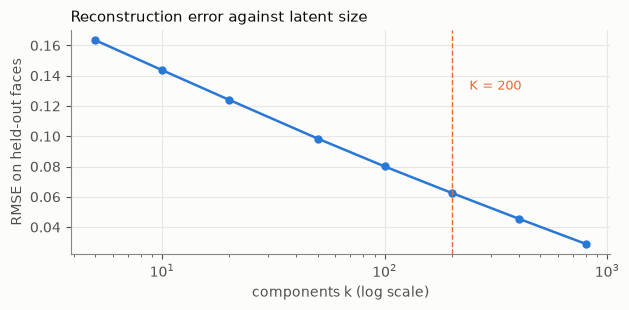

,train variance kept,valid RMSE,valid RMSE (grey levels /255),compression
k,,,,
5,0.5672,0.1635,41.6899,460.80
10,0.6674,0.1437,36.6316,230.40
20,0.7527,0.1240,31.6314,115.20
50,0.8448,0.0985,25.1078,46.08
100,0.8981,0.0800,20.4098,23.04
200,0.9387,0.0626,15.9518,11.52
400,0.9685,0.0455,11.6134,5.76
800,0.9881,0.0289,7.3716,2.88


In [12]:
rows = []
for k in ladder:
    model_k = truncate_pca(pca_full, k)
    recon = model_k.inverse_transform(model_k.transform(X_valid))
    rmse = float(np.sqrt(((recon - X_valid) ** 2).mean()))
    rows.append({"k": k,
                 "train variance kept": float(np.cumsum(evr)[k - 1]),
                 "valid RMSE": rmse,
                 "valid RMSE (grey levels /255)": rmse * 255,
                 "compression": N_PIXELS / k})
recon_table = pd.DataFrame(rows).set_index("k")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(recon_table.index, recon_table["valid RMSE"], "o-", color=C_BLUE, lw=1.8, ms=5)
ax.axvline(K, color=C_ORANGE, ls="--", lw=1)
ax.annotate(f"K = {K}", (K, recon_table["valid RMSE"].max() * 0.8),
            xytext=(K + 40, recon_table["valid RMSE"].max() * 0.8),
            color=C_ORANGE, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("components k (log scale)")
ax.set_ylabel("RMSE on held-out faces")
ax.set_title("Reconstruction error against latent size", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

recon_table.round(4)

**The compressor works.** At $k = 20$ every face is still the same generic blur; by
$k \approx 50$ pose, hair mass and expression are back; by $k \approx 100$ the person is
unmistakable and accessories such as a pair of glasses reappear. At $k = 200$ the held-out
RMSE is **0.063**, i.e. about **16 grey levels out of 255** per pixel, and what is still
missing is only fine texture — individual hair strands, skin detail, the *sharp* edge of
those glasses. The mouth, the eyes and the overall pose survive intact, which is all the
editing step needs.

Note that the RMSE is computed on the **validation** faces, which the PCA never saw. The
error curve on unseen data falls just as smoothly as the training variance curve rises —
the subspace generalises; it is a property of human faces, not a memorisation of these
28 709 of them.

## 3. The smile direction

Now the interesting part. Encode every face and take the **difference of the two class
means** in latent space,

$$ d \;=\; \bar{z}_{\text{happy}} - \bar{z}_{\text{sad}} \;\in\; \mathbb{R}^{200}. $$

Because the encoder is linear, this is *identical* to encoding the difference of the two
mean images: $\bar{z}_H - \bar{z}_S = W(\bar{x}_H - \mu) - W(\bar{x}_S - \mu) = W(\bar{x}_H - \bar{x}_S)$.
Nothing about PCA is required to define $d$ — but PCA is what lets us *use* it, because we
need to decode $z + \alpha d$ afterwards, and doing the same arithmetic in raw pixel space
would just superimpose a ghost of the average happy face on top of the original.

Both means are computed on the **training fold only**.

In [13]:
Z_train, enc_seconds = timed(lambda: pca.transform(X_train))
Z_valid = pca.transform(X_valid)
print(f"encoded {len(X_train)} + {len(X_valid)} faces in {enc_seconds:.1f}s")
print(f"Z_train {Z_train.shape}   Z_valid {Z_valid.shape}")

mean_happy = Z_train[y_train == HAPPY].mean(axis=0)
mean_sad = Z_train[y_train == SAD].mean(axis=0)
d = mean_happy - mean_sad

print(f"\nhappy faces used: {(y_train == HAPPY).sum()},  sad faces used: {(y_train == SAD).sum()}")
print(f"||d|| = {np.linalg.norm(d):.3f}")
print(f"mean ||z|| of a face = {np.linalg.norm(Z_train, axis=1).mean():.3f}"
      f"   ->  d is a {np.linalg.norm(d) / np.linalg.norm(Z_train, axis=1).mean():.1%} nudge at alpha = 1")

encoded 28709 + 7178 faces in 0.1s
Z_train (28709, 200)   Z_valid (7178, 200)

happy faces used: 7215,  sad faces used: 4830
||d|| = 1.901
mean ||z|| of a face = 11.204   ->  d is a 17.0% nudge at alpha = 1


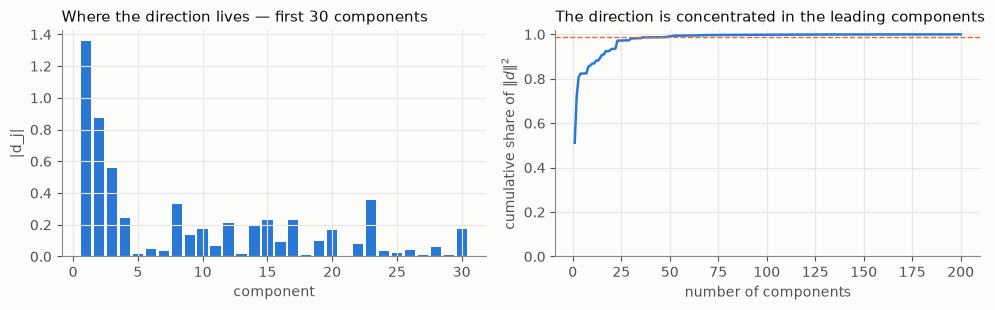

share of ||d||^2 in the first k components: {1: 0.512, 2: 0.722, 3: 0.807, 5: 0.824, 10: 0.868, 20: 0.934, 50: 0.991, 100: 0.999, 200: 1.0}
largest |d_j| at components: [1, 2, 3, 23, 8, 4, 15, 17]


In [14]:
energy = d ** 2
cum_energy = np.cumsum(energy) / energy.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.bar(np.arange(1, 31), np.abs(d[:30]), color=C_BLUE)
ax1.set_xlabel("component")
ax1.set_ylabel("|d_j|")
ax1.set_title("Where the direction lives — first 30 components", loc="left", fontsize=11)

ax2.plot(np.arange(1, K + 1), cum_energy, color=C_BLUE, lw=1.8)
ax2.axhline(0.99, color=C_ORANGE, ls="--", lw=1)
ax2.set_xlabel("number of components")
ax2.set_ylabel("cumulative share of $\\|d\\|^2$")
ax2.set_ylim(0, 1.02)
ax2.set_title("The direction is concentrated in the leading components", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

print("share of ||d||^2 in the first k components:",
      {k: round(float(cum_energy[k - 1]), 3) for k in (1, 2, 3, 5, 10, 20, 50, 100, 200)})
print("largest |d_j| at components:", (np.argsort(-np.abs(d))[:8] + 1).tolist())

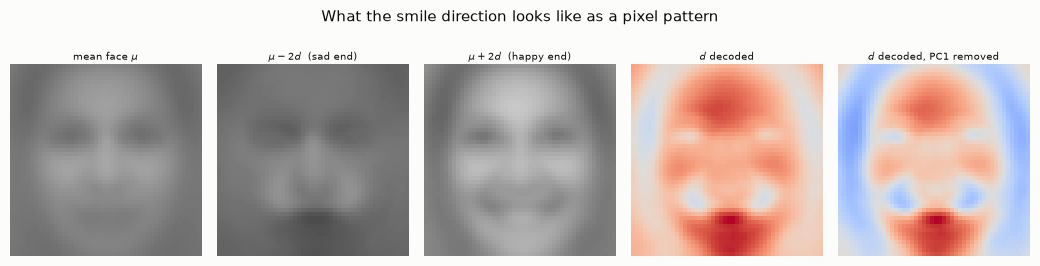

In [15]:
d_no_pc1 = d.copy()
d_no_pc1[0] = 0.0            # used in section 6 — kept here so both panels line up

fig, axes = plt.subplots(1, 5, figsize=(10.5, 2.6))
show_face(axes[0], pca.mean_, "mean face $\\mu$")
show_face(axes[1], (pca.inverse_transform((-2.0 * d)[None])[0]).clip(0, 1), "$\\mu - 2d$  (sad end)")
show_face(axes[2], (pca.inverse_transform((2.0 * d)[None])[0]).clip(0, 1), "$\\mu + 2d$  (happy end)")
show_signed(axes[3], d @ pca.components_, "$d$ decoded")
show_signed(axes[4], d_no_pc1 @ pca.components_, "$d$ decoded, PC1 removed")
fig.suptitle("What the smile direction looks like as a pixel pattern", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

**The direction is a smile.** Panels 2 and 3 walk the *mean face* — no individual
involved — from $\mu - 2d$ to $\mu + 2d$: the mouth goes from a narrow dark downturned
line to a wide bright band with lifted corners, the nasolabial folds deepen, and the eyes
narrow slightly. That is a smile, recovered without ever telling the model what a mouth
is.

Panel 4 shows $d$ decoded on its own (red = "add light here", blue = "remove light"). The
strongest single feature by far is the **broad red bar across the mouth** — the teeth /
lower-lip highlight that appears when a mouth opens into a smile — flanked by small blue
regions at the mouth corners and along the nasolabial line, exactly where a smile casts
shadow. There is also a red patch on the forehead and cheeks.

That forehead patch is the warning sign. The direction is not *only* about the mouth: it
also brightens the whole face. Panel 5 removes the PC1 (global-brightness) coordinate
from $d$ and re-decodes — the mouth bar survives unchanged while the uniform glow turns
into an ordinary contrast pattern. Section 6 measures how much of the effect each half is
responsible for.

**Effect size.** Before morphing anything, it is worth asking how well $d$ separates the
two classes on its own — how much of a smile is a *shift of a distribution* rather than a
property of an individual face.

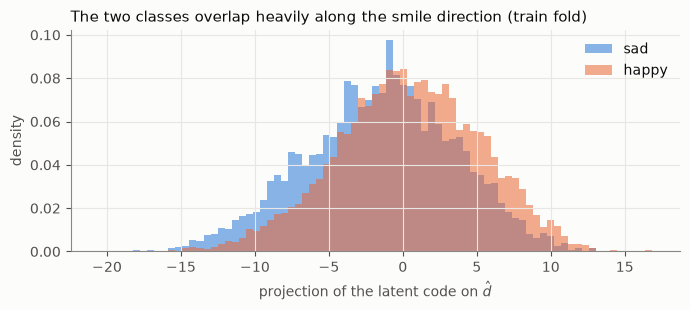

happy: mean +0.392  sd 4.860
sad  : mean -1.508  sd 5.067
Cohen's d = 0.384
note: the gap between the class means along d-hat is exactly ||d|| = 1.901


In [16]:
d_hat = d / np.linalg.norm(d)
proj_train = Z_train @ d_hat

fig, ax = plt.subplots(figsize=(7.0, 3.2))
bins = np.linspace(proj_train.min(), proj_train.max(), 80)
for name, cls, color in [("sad", SAD, C_BLUE), ("happy", HAPPY, C_ORANGE)]:
    ax.hist(proj_train[y_train == cls], bins=bins, density=True, alpha=0.55,
            color=color, label=name)
ax.set_xlabel(r"projection of the latent code on $\hat{d}$")
ax.set_ylabel("density")
ax.legend(frameon=False)
ax.set_title("The two classes overlap heavily along the smile direction (train fold)",
             loc="left", fontsize=11)
plt.tight_layout()
plt.show()

ph, ps = proj_train[y_train == HAPPY], proj_train[y_train == SAD]
pooled = np.sqrt(((len(ph) - 1) * ph.var(ddof=1) + (len(ps) - 1) * ps.var(ddof=1))
                 / (len(ph) + len(ps) - 2))
print(f"happy: mean {ph.mean():+.3f}  sd {ph.std():.3f}")
print(f"sad  : mean {ps.mean():+.3f}  sd {ps.std():.3f}")
print(f"Cohen's d = {(ph.mean() - ps.mean()) / pooled:.3f}")
print(f"note: the gap between the class means along d-hat is exactly ||d|| = {np.linalg.norm(d):.3f}")

**Cohen's $d \approx 0.38$ — a small-to-medium effect.** The histograms overlap almost
completely. This is the single most important caveat of the whole notebook and it should
be stated before the pretty pictures, not after them: **$d$ is not a smile detector.**
The within-class spread along $\hat d$ (sd $\approx 4.9$) is more than twice the distance
between the class means ($\|d\| = 1.90$). Individual identity, pose and lighting move a
face along $\hat d$ far more than its expression does.

What that implies for the morph is precise and testable: adding $\alpha d$ shifts a face
by a fixed amount in a direction along which the happy and sad populations differ *on
average*. It will reliably move the **population** of morphed faces toward the happy
distribution — which is what we measure in section 5 — while on any **single** face the
result ranges from a convincing smile to almost no visible change. Section 4 shows both.

## 4. Morphing: $z' = z + \alpha d$

The edit is three lines — encode, translate, decode:

```python
z = pca.transform(face)          # 2304 -> 200
z_new = z + alpha * d            # walk along the smile direction
new_face = pca.inverse_transform(z_new)   # 200 -> 2304
```

$\alpha = 1$ moves a face by exactly the distance between the two class means: it takes
the *average* sad face to the *average* happy face. Negative $\alpha$ walks the other way.
We show $\alpha$ up to $3$ deliberately, past the point where the result stays plausible,
because that is where the method's limits become visible.

**How the example faces are chosen.** All morphed faces come from the **validation fold**.
Picking the faces where the *edit* looks best would be cherry-picking, so we do not do
that. Instead we sample at random from the quartile of faces the *compressor*
reconstructs best (lowest reconstruction RMSE at $\alpha = 0$). That is a criterion about
step 1, decided before the direction is ever applied — a face the PCA cannot represent
cannot be meaningfully edited either, and including badly-reconstructed profile shots
would only measure the compressor's failure. The third panel then shows a **completely
unfiltered random sample** so the typical case is on the record too.

In [17]:
recon_valid = pca.inverse_transform(Z_valid)
recon_err_valid = np.sqrt(((recon_valid - X_valid) ** 2).mean(axis=1))
print("validation reconstruction RMSE quartiles:",
      np.round(np.quantile(recon_err_valid, [0, .25, .5, .75, 1]), 4).tolist())


def morph(z, vec, alpha):
    """Decode ``z + alpha * vec`` back to pixels, clipped to the displayable range."""
    return pca.inverse_transform(np.atleast_2d(z) + alpha * vec).clip(0, 1)


def pick_faces(cls, n, well_reconstructed=True, generator=None):
    """n validation faces of class ``cls``; optionally from the best-reconstructed quartile."""
    pool = np.flatnonzero(y_valid == cls)
    if well_reconstructed:
        pool = pool[recon_err_valid[pool] <= np.quantile(recon_err_valid[pool], 0.25)]
    return (generator or rng).choice(pool, n, replace=False)


def morph_strip(indices, alphas, vec, title):
    fig, axes = plt.subplots(len(indices), len(alphas) + 1,
                             figsize=(1.02 * (len(alphas) + 1), 1.02 * len(indices) + 0.35))
    for row, idx in enumerate(indices):
        show_face(axes[row, 0], X_valid[idx], "original" if row == 0 else None)
        for col, a in enumerate(alphas):
            show_face(axes[row, col + 1], morph(Z_valid[idx], vec, a)[0],
                      f"$\\alpha={a:+.1f}$" if row == 0 else None)
    fig.suptitle(title, fontsize=11, y=1.0)
    plt.tight_layout()
    plt.show()


ALPHAS_UP = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
ALPHAS_DOWN = [0.0, -0.5, -1.0, -1.5, -2.0, -3.0]
strip_rng = np.random.default_rng(RANDOM_STATE)

validation reconstruction RMSE quartiles: [0.0019, 0.0484, 0.0585, 0.0694, 0.2128]


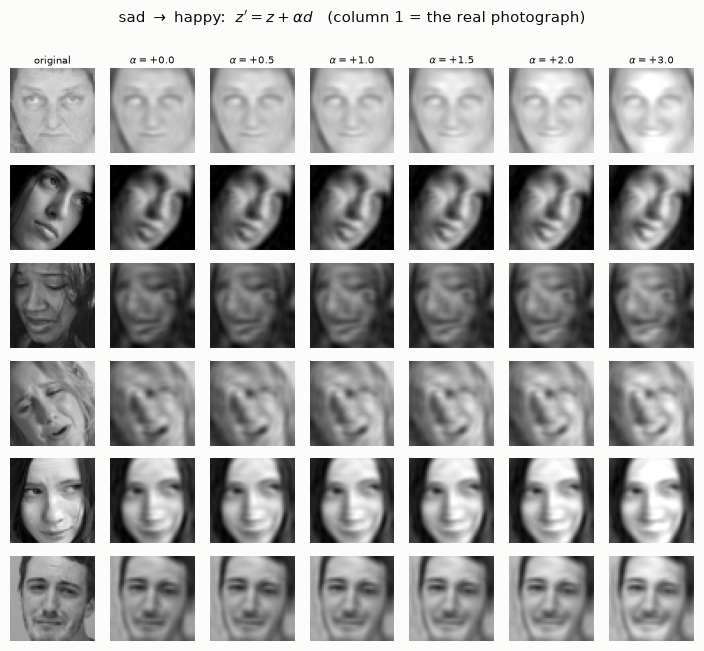

In [18]:
sad_examples = pick_faces(SAD, 6, generator=strip_rng)
morph_strip(sad_examples, ALPHAS_UP, d,
            "sad $\\rightarrow$ happy:  $z' = z + \\alpha d$   (column 1 = the real photograph)")

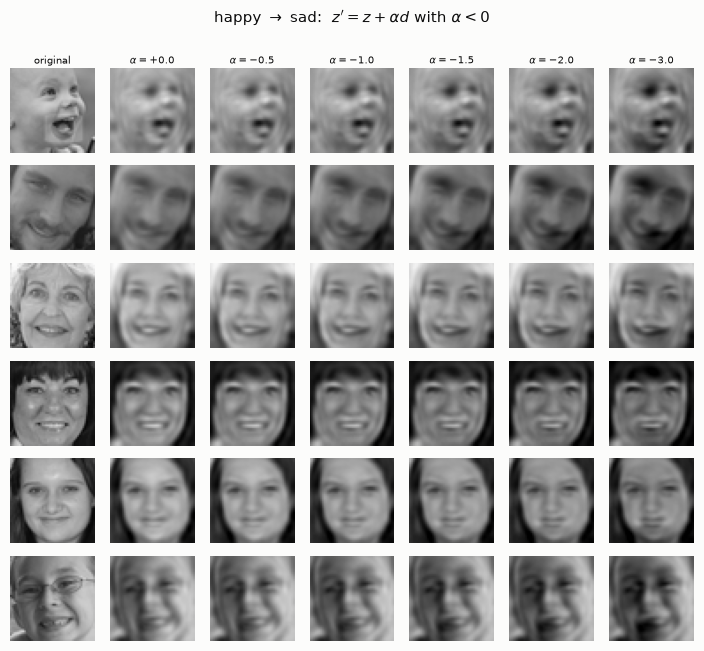

In [19]:
happy_examples = pick_faces(HAPPY, 6, generator=strip_rng)
morph_strip(happy_examples, ALPHAS_DOWN, d,
            "happy $\\rightarrow$ sad:  $z' = z + \\alpha d$ with $\\alpha < 0$")

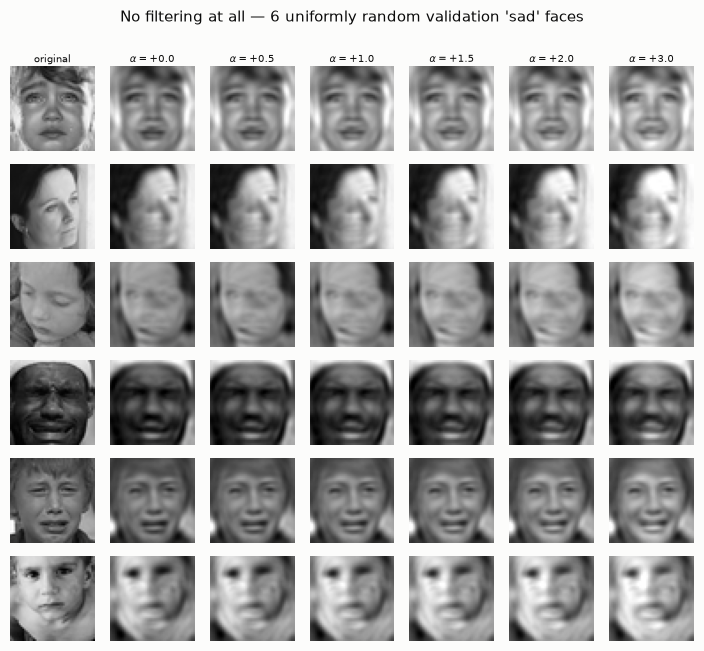

In [20]:
random_sad = pick_faces(SAD, 6, well_reconstructed=False, generator=strip_rng)
morph_strip(random_sad, ALPHAS_UP, d,
            "No filtering at all — 6 uniformly random validation 'sad' faces")

**What actually happens.**

*Sad → happy.* Column 2 ($\alpha = 0$) is the PCA reconstruction, so the honest comparison
is column 2 against the rest, not column 1. Moving right, the mouth widens and a bright
lower-lip / teeth band appears, the corners lift, and the cheeks fill out; on the clearest
rows the face is unambiguously smiling by $\alpha = 1.5$–$2$. Identity survives well up to
about $\alpha = 1.5$ — hair, face shape, glasses and head angle are all preserved, because
$d$ is a *fixed offset*, so everything about $z$ that is not along $d$ is untouched.

*Happy → sad.* The same vector run backwards closes the smile: the bright teeth band fades,
the mouth line flattens and then turns down, and the whole face darkens. It is noticeably
easier to remove a smile than to install one — unsurprising, since an open smiling mouth
is a high-variance, high-contrast feature that the leading components represent well.

*The unfiltered sample.* Roughly half of it still works — a smile appears on the frontal,
reasonably centred faces. The other half shows the limit: a face in profile, a strongly
tilted head, a crop where the head is much smaller than usual. Those reconstruct badly at
$\alpha = 0$ already, and adding $\alpha d$ to them only paints a frontal-mouth-shaped
smear somewhere that is not where their mouth actually is. FER-2013 is not registered,
and $d$ is an *average* over thousands of differently-positioned mouths, so it can only be
correct for a face whose mouth sits near the average position. That "roughly half" is the
honest success rate on unfiltered data, and it is a property of the dataset rather than of
the method.

*At $\alpha = 3$* everything degrades: the face washes out toward white, ghost edges appear
around the jaw and hairline, and the result stops looking like a photograph. Section 7
measures that.

None of the above is proof — it is six faces and an author's description of them. The next
section replaces the description with a number.

## 5. Does it actually work? Three probe classifiers

Claiming a picture "looks happier" is not evidence. So we train **happy-vs-sad
classifiers on the training fold**, morph **validation** faces across a grid of $\alpha$,
and track the mean predicted $P(\text{happy})$. If the morph is real, that curve rises
monotonically with $\alpha$ for sad sources and falls for happy sources.

Three probes, chosen so their weaknesses do not overlap:

| probe | input | why it is here |
|---|---|---|
| **LogReg** | 200-d latent | the standard baseline — but see the caveat below |
| **MLP (128 hidden units)** | 200-d latent | **non-linear**, so a monotone response is not automatic |
| **Random forest** | 2304 raw pixels of the **decoded** image | never sees the latent space at all — fully basis-independent |

**The caveat that makes the third row necessary.** For a linear model the logit of a
morphed face is
$$ w^{\mathsf T}(z + \alpha d) + b \;=\; \underbrace{w^{\mathsf T} z + b}_{\text{original}} \;+\; \alpha\,(w^{\mathsf T} d), $$
i.e. **exactly linear in $\alpha$**. Since $w$ and $d$ both point from sad toward happy,
$w^{\mathsf T}d > 0$ is close to guaranteed and the logistic-regression curve *must* be a
rising sigmoid. It measures the effect *size*, not its existence. The MLP and the
pixel-space forest carry no such guarantee: their decision surfaces are curved, so they
will only report a rising probability if the morphed points actually land where the real
happy faces live.

In [21]:
mask_train = (y_train == HAPPY) | (y_train == SAD)
mask_valid = (y_valid == HAPPY) | (y_valid == SAD)
Zp_train, tp_train = Z_train[mask_train], (y_train[mask_train] == HAPPY).astype(int)
Zp_valid, tp_valid = Z_valid[mask_valid], (y_valid[mask_valid] == HAPPY).astype(int)
Xp_train, Xp_valid = X_train[mask_train], X_valid[mask_valid]
print(f"probe training set: {Zp_train.shape[0]} faces "
      f"({tp_train.sum()} happy / {(1 - tp_train).sum()} sad)")
print(f"probe test set    : {Zp_valid.shape[0]} faces (validation fold, never used above)")

probes = {}
probes["LogReg (latent)"], t1 = timed(
    lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Zp_train, tp_train))
probes["MLP (latent)"], t2 = timed(
    lambda: make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(128,), max_iter=60, early_stopping=True,
                      random_state=RANDOM_STATE)).fit(Zp_train, tp_train))
probes["RandomForest (pixels)"], t3 = timed(
    lambda: RandomForestClassifier(n_estimators=200, min_samples_leaf=3, n_jobs=-1,
                                   random_state=RANDOM_STATE).fit(Xp_train, tp_train))
print(f"\nfit times: LogReg {t1:.1f}s | MLP {t2:.1f}s | RandomForest {t3:.1f}s")

PIXEL_PROBES = {"RandomForest (pixels)"}


def probe_proba(name, Z):
    """P(happy) for a batch of latent codes, decoding first for the pixel-space probe."""
    Q = pca.inverse_transform(Z).clip(0, 1) if name in PIXEL_PROBES else Z
    return probes[name].predict_proba(Q)[:, 1]


quality = pd.DataFrame([
    {"probe": name,
     "accuracy (valid)": accuracy_score(tp_valid, (probe_proba(name, Zp_valid) > 0.5).astype(int)),
     "ROC AUC (valid)": roc_auc_score(tp_valid, probe_proba(name, Zp_valid))}
    for name in probes
]).set_index("probe")
quality.round(4)

probe training set: 12045 faces (7215 happy / 4830 sad)
probe test set    : 3021 faces (validation fold, never used above)



fit times: LogReg 2.0s | MLP 13.1s | RandomForest 10.5s


,accuracy (valid),ROC AUC (valid)
probe,,
LogReg (latent),0.7236,0.7790
MLP (latent),0.7517,0.8169
RandomForest (pixels),0.7335,0.8166


The probes reach **72–75 % accuracy / 0.78–0.82 AUC** on held-out happy-vs-sad. That is
modest — a convolutional network gets into the high 80s on this pair — but it is exactly
what we need: a probe that is clearly better than chance and was trained *without ever
seeing a morphed image*. Its opinion about our synthetic faces is therefore an outside
opinion.

In [22]:
ALPHA_GRID = np.round(np.linspace(-0.5, 2.0, 11), 3)
Z_sad_valid = Z_valid[y_valid == SAD]
Z_happy_valid = Z_valid[y_valid == HAPPY]
print(f"morphing {len(Z_sad_valid)} validation sad faces and "
      f"{len(Z_happy_valid)} validation happy faces at {len(ALPHA_GRID)} values of alpha")

records = []
for name in probes:
    for a in ALPHA_GRID:
        records.append({"probe": name, "alpha": a, "source": "sad source",
                        "P(happy)": float(probe_proba(name, Z_sad_valid + a * d).mean())})
        records.append({"probe": name, "alpha": a, "source": "happy source",
                        "P(happy)": float(probe_proba(name, Z_happy_valid - a * d).mean())})
curves = pd.DataFrame(records)

# Reference points: what each probe says about the REAL, unmorphed validation faces.
reference = {name: {"real sad": float(probe_proba(name, Z_sad_valid).mean()),
                    "real happy": float(probe_proba(name, Z_happy_valid).mean())}
             for name in probes}
print(pd.DataFrame(reference).T.round(3).to_string(), "\n")

pivot = curves.pivot_table(index="alpha", columns=["source", "probe"], values="P(happy)")
pivot.round(3)

morphing 1247 validation sad faces and 1774 validation happy faces at 11 values of alpha


                       real sad  real happy
LogReg (latent)           0.465       0.684
MLP (latent)              0.400       0.737
RandomForest (pixels)     0.495       0.688 



source    happy source                                         sad source  \
probe  LogReg (latent) MLP (latent) RandomForest (pixels) LogReg (latent)   
alpha                                                                       
-0.50            0.773        0.809                 0.731           0.357   
-0.25            0.730        0.775                 0.711           0.410   
 0.00            0.684        0.737                 0.688           0.465   
 0.25            0.634        0.696                 0.662           0.520   
 0.50            0.582        0.652                 0.635           0.575   
 0.75            0.527        0.606                 0.606           0.629   
 1.00            0.472        0.559                 0.577           0.679   
 1.25            0.418        0.511                 0.545           0.726   
 1.50            0.366        0.463                 0.515           0.769   
 1.75            0.316        0.416                 0.485           0.807   
 2.00            0.269        0.370                 0.457           0.841   

source                                     
probe  MLP (latent) RandomForest (pixels)  
alpha                                      
-0.50         0.308                 0.442  
-0.25         0.353                 0.468  
 0.00         0.400                 0.495  
 0.25         0.451                 0.522  
 0.50         0.503                 0.550  
 0.75         0.555                 0.578  
 1.00         0.607                 0.606  
 1.25         0.657                 0.631  
 1.50         0.704                 0.654  
 1.75         0.748                 0.676  
 2.00         0.788                 0.695

The raw probabilities are hard to read on their own, because the probes are not perfect
and not calibrated: they already give the *real* sad faces some probability of being happy
and the *real* happy faces well under 1. The meaningful question is not "did it cross
0.5?" but **"does a morphed sad face score like a real happy face?"** So we rescale each
curve onto the interval its own probe assigns to the two real populations,

$$ \text{progress}(\alpha) \;=\;
   \frac{\bar{P}(\alpha) - \bar{P}_{\text{real sad}}}{\bar{P}_{\text{real happy}} - \bar{P}_{\text{real sad}}}, $$

so 0 means "still scores like the real sad faces", 1 means "scores like the real happy
faces", and the two probes become comparable.

In [23]:
progress = []
for name in probes:
    lo, hi = reference[name]["real sad"], reference[name]["real happy"]
    s = curves[(curves["source"] == "sad source") & (curves["probe"] == name)]
    progress.append(pd.Series(((s.set_index("alpha")["P(happy)"] - lo) / (hi - lo)).values,
                              index=s["alpha"].values, name=name))
progress = pd.DataFrame(progress).T
progress.index.name = "alpha"

for name in probes:
    reached = progress.index[progress[name] >= 1.0]
    where = f"alpha = {reached[0]:.2f}" if len(reached) else "not reached on this grid"
    print(f"{name:24s} progress at alpha=1: {progress.loc[1.0, name]:5.1%}   "
          f"reaches the real-happy level at {where}")
progress.round(3)

LogReg (latent)          progress at alpha=1: 97.8%   reaches the real-happy level at alpha = 1.25
MLP (latent)             progress at alpha=1: 61.3%   reaches the real-happy level at alpha = 1.75
RandomForest (pixels)    progress at alpha=1: 57.3%   reaches the real-happy level at alpha = 2.00


,LogReg (latent),MLP (latent),RandomForest (pixels)
alpha,,,
-0.50,-0.490,-0.274,-0.272
-0.25,-0.250,-0.142,-0.140
0.00,-0.000,-0.000,0.000
0.25,0.253,0.149,0.137
0.50,0.504,0.303,0.285
0.75,0.747,0.459,0.430
1.00,0.978,0.613,0.573
1.25,1.192,0.762,0.701
1.50,1.387,0.903,0.823


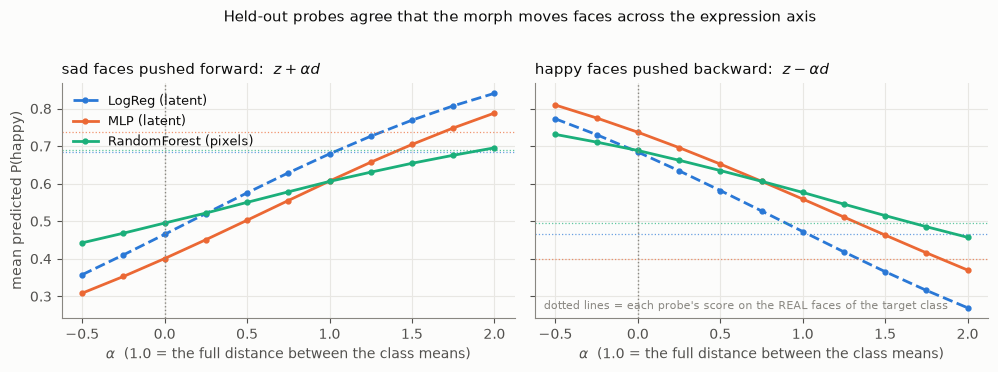

sad source  (expected: P(happy) rising with alpha)
  LogReg (latent)          alpha=0: 0.465 -> alpha=1: 0.679 -> alpha=2: 0.841   (strictly rising over all 11 steps)
  MLP (latent)             alpha=0: 0.400 -> alpha=1: 0.607 -> alpha=2: 0.788   (strictly rising over all 11 steps)
  RandomForest (pixels)    alpha=0: 0.495 -> alpha=1: 0.606 -> alpha=2: 0.695   (strictly rising over all 11 steps)
happy source  (expected: P(happy) falling with alpha)
  LogReg (latent)          alpha=0: 0.684 -> alpha=1: 0.472 -> alpha=2: 0.269   (strictly falling over all 11 steps)
  MLP (latent)             alpha=0: 0.737 -> alpha=1: 0.559 -> alpha=2: 0.370   (strictly falling over all 11 steps)
  RandomForest (pixels)    alpha=0: 0.688 -> alpha=1: 0.577 -> alpha=2: 0.457   (strictly falling over all 11 steps)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), sharey=True)
styles = {"LogReg (latent)": (C_BLUE, "--"),
          "MLP (latent)": (C_ORANGE, "-"),
          "RandomForest (pixels)": (C_AQUA, "-")}
titles = {"sad source": r"sad faces pushed forward:  $z + \alpha d$",
          "happy source": r"happy faces pushed backward:  $z - \alpha d$"}

for ax, source in zip(axes, ["sad source", "happy source"]):
    sub = curves[curves["source"] == source]
    target = "real happy" if source == "sad source" else "real sad"
    for name, (color, ls) in styles.items():
        s = sub[sub["probe"] == name]
        ax.plot(s["alpha"], s["P(happy)"], ls, color=color, lw=2, marker="o", ms=3.5, label=name)
        ax.axhline(reference[name][target], color=color, lw=0.9, ls=":", alpha=0.7)
    ax.axvline(0.0, color=MUTED, lw=1, ls=":")
    ax.set_xlabel(r"$\alpha$  (1.0 = the full distance between the class means)")
    ax.set_title(titles[source], loc="left", fontsize=11)
axes[0].set_ylabel("mean predicted P(happy)")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
axes[1].annotate("dotted lines = each probe's score on the REAL faces of the target class",
                 xy=(0.02, 0.04), xycoords="axes fraction", fontsize=8, color=MUTED)
fig.suptitle("Held-out probes agree that the morph moves faces across the expression axis",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

for source, want in [("sad source", "rising"), ("happy source", "falling")]:
    print(f"{source}  (expected: P(happy) {want} with alpha)")
    for name in probes:
        s = curves[(curves["source"] == source) & (curves["probe"] == name)].set_index("alpha")["P(happy)"]
        steps = np.diff(s.values)
        ok = (steps > 0).all() if want == "rising" else (steps < 0).all()
        print(f"  {name:24s} alpha=0: {s.loc[0.0]:.3f} -> alpha=1: {s.loc[1.0]:.3f}"
              f" -> alpha=2: {s.loc[2.0]:.3f}   "
              f"({'strictly ' + want if ok else 'NOT ' + want} over all 11 steps)")

**This is the quantitative evidence.** All six curves are *strictly* monotone across all
eleven steps of the grid — rising for sad sources, falling for happy sources, for every
probe.

Taking the **MLP** — non-linear, so nothing forces this — on the 1 247 validation *sad*
faces: mean $P(\text{happy})$ climbs **0.400 → 0.607 → 0.788** as $\alpha$ goes
$0 \to 1 \to 2$. In normalised terms it covers **61 %** of the distance from the real-sad
level to the real-happy level at $\alpha = 1$, and passes the real-happy level itself at
$\alpha \approx 1.75$.

The **pixel-space random forest** is the strongest result in the notebook. It was trained
on raw 48×48 photographs and knows nothing about PCA, eigenfaces or $d$; we hand it the
*decoded* morphed images as if they were ordinary photos. It reports **0.495 → 0.606 →
0.695**, i.e. **57 %** of the way to the real-happy level at $\alpha = 1$. An independent
observer, looking only at pixels, sees the faces getting happier.

Run backwards on the 1 774 validation *happy* faces the effect mirrors: the MLP falls
**0.737 → 0.559 → 0.370** and the forest **0.688 → 0.577 → 0.457**, in both cases sailing
past the level those probes assign to real sad faces. Smiles are being removed as well as
added — and the backward edit is if anything the more effective of the two, which matches
what the strips looked like.

The **logistic regression** curve (dashed) is the textbook sigmoid the algebra above
predicts, and should be read only as a scale: $\alpha = 1$ is worth about
$w^{\mathsf T}d \approx 0.9$ logits.

Three honest qualifications.

* The probes are only ~73 % accurate, so they already assign the *real* sad faces
  $P(\text{happy}) \approx 0.40$–0.50 and the *real* happy faces only $\approx 0.69$–0.74.
  That is why the raw curves cross 0.5 early (around $\alpha \approx 0.5$ for the MLP) —
  crossing 0.5 is a statement about the probe's calibration, not about the morph. The
  normalised "progress" column is the number to read, and by that measure it takes
  $\alpha \approx 1.25$–2 to carry the population all the way to the real-happy level.
* The effect is a shift of the *mean* of a broad distribution. It does not follow, and is
  not true, that every individual face crosses over — consistent with the Cohen's
  $d = 0.38$ we measured in section 3.
* The probes and the direction were estimated on the same training fold, so they share its
  biases (see section 6). What they do not share is the morphed *data*: every face scored
  here is a validation face neither of them was fitted on.

## 6. What else is in the direction? The brightness confound

A difference of class means picks up **every** systematic difference between the two
groups of photographs, not just the expression. The bar chart in section 3 showed that
**51 % of $\|d\|^2$ sits in PC1 alone**, and PC1 is the global-brightness component. So
before believing the story, we have to rule out the boring explanation: *maybe the probes
just like bright pictures.*

In [25]:
print(f"corr(PC1 score, mean image intensity) = "
      f"{np.corrcoef(Z_train[:, 0], X_train.mean(axis=1))[0, 1]:.3f}")
print(f"corr(PC2 score, mean image intensity) = "
      f"{np.corrcoef(Z_train[:, 1], X_train.mean(axis=1))[0, 1]:.3f}")

brightness = (pd.DataFrame({"emotion": label_names,
                            "mean intensity": [float(X[y == i].mean()) for i in range(len(label_names))]})
              .set_index("emotion").sort_values("mean intensity"))
print()
brightness.round(4)

corr(PC1 score, mean image intensity) = 0.994
corr(PC2 score, mean image intensity) = -0.088



,mean intensity
emotion,
sad,0.4746
neutral,0.4858
angry,0.4962
happy,0.5062
disgust,0.5298
fear,0.5311
surprise,0.5736


In [26]:
variants = {
    "d (as defined)": d,
    "d without PC1": d_no_pc1,
    "PC1 component only": np.where(np.arange(K) == 0, d, 0.0),
    "d truncated to top 50": np.where(np.arange(K) < 50, d, 0.0),
}

rows = []
for name, vec in variants.items():
    for a in [0.0, 0.5, 1.0, 1.5, 2.0]:
        morphed = pca.inverse_transform(Z_sad_valid + a * vec).clip(0, 1)
        rows.append({"direction": name, "||v||": float(np.linalg.norm(vec)), "alpha": a,
                     "P(happy) [MLP]": float(probe_proba("MLP (latent)", Z_sad_valid + a * vec).mean()),
                     "mean brightness": float(morphed.mean())})
confound = pd.DataFrame(rows)
confound.pivot_table(index="alpha", columns="direction",
                     values=["P(happy) [MLP]", "mean brightness"]).round(3)

P(happy) [MLP]                                       \
direction PC1 component only d (as defined) d truncated to top 50   
alpha                                                               
0.0                    0.400          0.400                 0.400   
0.5                    0.404          0.503                 0.481   
1.0                    0.407          0.607                 0.562   
1.5                    0.411          0.704                 0.642   
2.0                    0.414          0.788                 0.715   

                           mean brightness                 \
direction d without PC1 PC1 component only d (as defined)   
alpha                                                       
0.0               0.400              0.471          0.471   
0.5               0.499              0.485          0.487   
1.0               0.601              0.498          0.503   
1.5               0.697              0.512          0.518   
2.0               0.780              0.526          0.534   

                                               
direction d truncated to top 50 d without PC1  
alpha                                          
0.0                       0.471         0.471  
0.5                       0.487         0.473  
1.0                       0.503         0.476  
1.5                       0.519         0.478  
2.0                       0.534         0.480

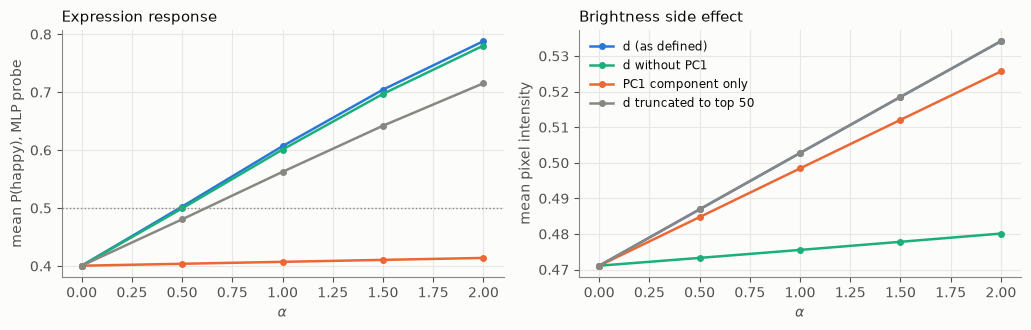

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.4))
colors = {"d (as defined)": C_BLUE, "d without PC1": C_AQUA,
          "PC1 component only": C_ORANGE, "d truncated to top 50": MUTED}
for name, color in colors.items():
    s = confound[confound["direction"] == name]
    ax1.plot(s["alpha"], s["P(happy) [MLP]"], "o-", color=color, lw=1.8, ms=4, label=name)
    ax2.plot(s["alpha"], s["mean brightness"], "o-", color=color, lw=1.8, ms=4, label=name)
ax1.axhline(0.5, color=MUTED, lw=1, ls=":")
ax1.set_xlabel(r"$\alpha$"); ax1.set_ylabel("mean P(happy), MLP probe")
ax1.set_title("Expression response", loc="left", fontsize=11)
ax2.set_xlabel(r"$\alpha$"); ax2.set_ylabel("mean pixel intensity")
ax2.set_title("Brightness side effect", loc="left", fontsize=11)
ax2.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

**The confound is real, and it is not what is driving the effect.** Three readings of the
table:

1. **PC1 really is brightness.** Its score correlates **0.994** with the mean intensity of
   the image, and the class means confirm the bias: happy faces average 0.506 intensity
   against 0.475 for sad ones — the photographs of smiling people in this dataset are
   genuinely brighter. So $d$ *had* to pick up a brightness component, and it did:
   half its squared length.

2. **PC1 alone does almost nothing.** Walking along only the PC1 part of $d$ raises the
   mean brightness from 0.471 to 0.526 — the full effect — while the MLP's
   $P(\text{happy})$ moves only **0.400 → 0.414**. Making a face brighter does not make
   the probe call it happy.

3. **Removing PC1 costs almost nothing.** The de-confounded direction $d$ with its PC1
   coordinate zeroed reaches **0.780** at $\alpha = 2$ against 0.788 for the full
   direction, while leaving brightness essentially flat (0.471 → 0.480). Panel 5 of
   section 3 confirms the mouth bar is untouched by the removal.

So the expression signal lives in **PC2 and beyond** — the shape components — and the
brightness content of $d$ is a passenger. If this were a production system, `d_no_pc1` is
the direction to ship: same effect, no lighting artefact.

The fourth variant answers the "should we denoise $d$ by keeping only its leading
coordinates?" question, and the answer is **no**: truncating to the top 50 components
keeps 99.1 % of $\|d\|^2$ yet drops $P(\text{happy})$ at $\alpha = 2$ from 0.788 to
**0.715**. Those last 150 small coefficients are not noise — they carry the fine mouth and
eye detail that the coarse components cannot express, and they matter more than their tiny
share of the norm suggests.

## 7. Failure modes

Everything above is a linear extrapolation inside a 200-dimensional subspace fitted to
real faces. Nothing constrains $z + \alpha d$ to stay in the region of that subspace where
faces actually live, and for large $\alpha$ it does not.

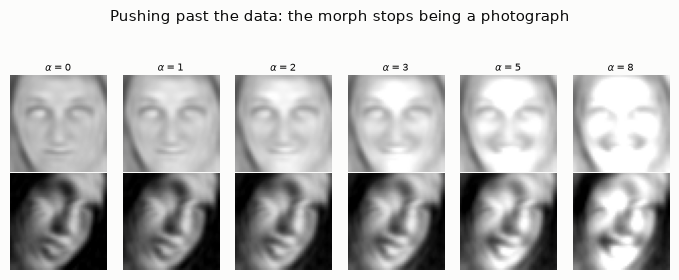

,"% pixels outside [0,1]",mean brightness (clipped),mean |z'| / mean |z|
alpha,,,
0.0,1.532,0.471,1.000
1.0,1.559,0.503,0.989
2.0,2.372,0.534,1.005
3.0,3.973,0.565,1.046
5.0,9.509,0.622,1.193
8.0,21.459,0.694,1.530


In [28]:
big_alphas = np.array([0.0, 1.0, 2.0, 3.0, 5.0, 8.0])
rows = []
for a in big_alphas:
    raw = pca.inverse_transform(Z_sad_valid + a * d)
    rows.append({"alpha": a,
                 "% pixels outside [0,1]": 100 * float(((raw < 0) | (raw > 1)).mean()),
                 "mean brightness (clipped)": float(raw.clip(0, 1).mean()),
                 "mean |z'| / mean |z|": float(np.linalg.norm(Z_sad_valid + a * d, axis=1).mean()
                                               / np.linalg.norm(Z_sad_valid, axis=1).mean())})
off_manifold = pd.DataFrame(rows).set_index("alpha")

fig, axes = plt.subplots(2, len(big_alphas), figsize=(1.15 * len(big_alphas), 2.6))
for col, a in enumerate(big_alphas):
    for row, idx in enumerate(sad_examples[:2]):
        show_face(axes[row, col], morph(Z_valid[idx], d, a)[0],
                  f"$\\alpha={a:g}$" if row == 0 else None)
fig.suptitle("Pushing past the data: the morph stops being a photograph", fontsize=11, y=1.06)
plt.tight_layout()
plt.show()

off_manifold.round(3)

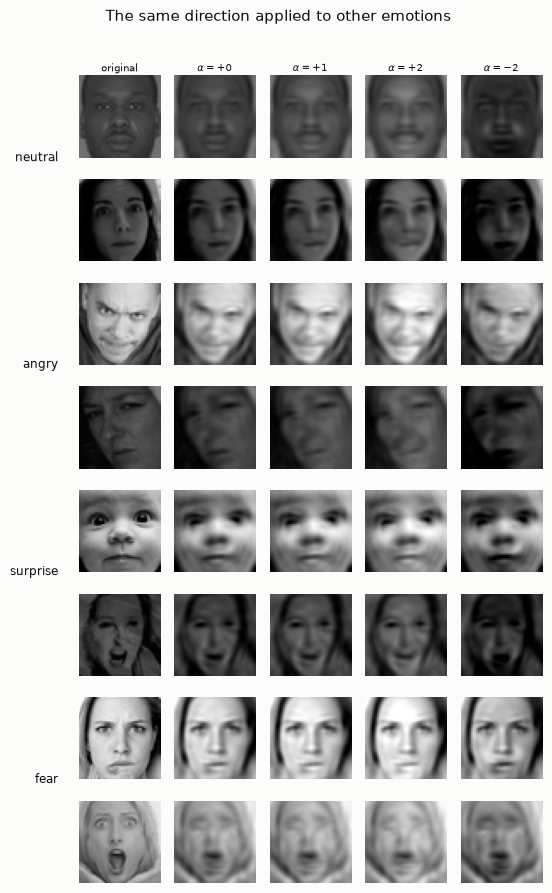

In [29]:
other_classes = ["neutral", "angry", "surprise", "fear"]
transfer_rng = np.random.default_rng(RANDOM_STATE + 1)
rows_ = 2 * len(other_classes)
fig, axes = plt.subplots(rows_, 5, figsize=(5.6, 1.05 * rows_ + 0.4))
for block, name in enumerate(other_classes):
    picks = pick_faces(LABEL_TO_ID[name], 2, generator=transfer_rng)
    for sub, idx in enumerate(picks):
        row = 2 * block + sub
        show_face(axes[row, 0], X_valid[idx], "original" if row == 0 else None)
        for col, a in enumerate([0.0, 1.0, 2.0, -2.0]):
            show_face(axes[row, col + 1], morph(Z_valid[idx], d, a)[0],
                      f"$\\alpha={a:+.0f}$" if row == 0 else None)
        if sub == 0:
            axes[row, 0].text(-0.25, 0.0, name, transform=axes[row, 0].transAxes,
                              ha="right", va="center", fontsize=8.5, color=INK)
fig.suptitle("The same direction applied to other emotions", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

**Where it breaks, and why.**

* **Off the manifold at large $\alpha$.** The table shows the mechanism. At $\alpha = 0$
  about **1.5 %** of decoded pixels already fall outside $[0, 1]$ (ordinary truncation
  error); by $\alpha = 2$ it is 2.4 %, by $\alpha = 3$ **4.0 %**, and by $\alpha = 8$ a
  catastrophic **21.5 %**. Those pixels are being *clipped* — a non-linearity the model
  knows nothing about — and that is exactly what the figure shows: at $\alpha = 5$ and 8
  the face floods to flat white and the eyes and mouth invert into dark cut-out shapes.
  The latent norm confirms the drift: it is essentially unchanged up to $\alpha = 2$
  (ratio 1.00 — the edit is small relative to a face's own length, and it even dips very
  slightly at $\alpha = 1$ because sad faces sit on the far side of the origin along $d$),
  then grows to 1.05 at $\alpha = 3$ and 1.53 at $\alpha = 8$. Useful range: roughly
  $|\alpha| \le 2$.
* **Blur.** Even at $\alpha = 0$ the output is a 200-component reconstruction, so fine
  texture is gone. A morph can only ever be as sharp as the compressor, and PCA's optimum
  in the least-squares sense is a blurry optimum: averaging is the safest way to minimise
  squared error.
* **Low squared error is not a quality certificate** — see the dedicated check below.
* **No registration.** FER-2013 faces are not aligned — no eye-centre normalisation, no
  common scale, no de-rotation. $d$ is an average over thousands of mouths at slightly
  different places, so it is a *smeared* mouth-edit that only lands correctly on a
  roughly frontal, roughly centred face. This is the single biggest limitation, and the
  cheapest fix: aligning the faces first (eye landmarks → similarity transform) would
  sharpen both the eigenfaces and the direction dramatically.
* **Label noise.** FER-2013's crowd-sourced labels are ~65 % accurate against expert
  consensus. A mislabelled face pulls the class mean toward the wrong group, which
  attenuates $d$ — the true expression direction is probably somewhat longer and cleaner
  than the one we estimated.
* **Demographic and pose confounds.** Beyond brightness, the happy and sad populations of
  this dataset differ in other ways a difference-of-means cannot separate — age mix (many
  of the clearest smiles are children), head pose, and how often teeth are visible. Some
  of those ride along in $d$. The PC1 analysis in section 6 shows how to detect such a
  passenger and how much it contributes; the same procedure would work for any other
  confound one can name a coordinate for.
* **It is one global direction.** The last figure applies the same $d$ to neutral, angry,
  surprised and fearful faces. It still adds and removes a smile — the direction is
  genuinely about mouth shape rather than about the "sad" class specifically — but it
  cannot know that lifting the mouth of a *surprised* face (already open) is a different
  edit from lifting the mouth of a *neutral* one. A per-face or non-linear editor
  (a conditional VAE, a StyleGAN latent direction) is what would fix this; PCA gets one
  vector for everybody.

### A closer look at "low reconstruction error"

Section 4 picked example faces from the best-reconstructed quartile, so it is worth
auditing what that criterion actually selects. RMSE is an *absolute* quantity, so a
low-contrast image gets a low score almost for free. Sorting the best-RMSE quartile by the
**relative** error $\mathrm{RMSE} / \operatorname{std}(x)$ finds the images that are only
"well reconstructed" because there was nothing there to reconstruct.

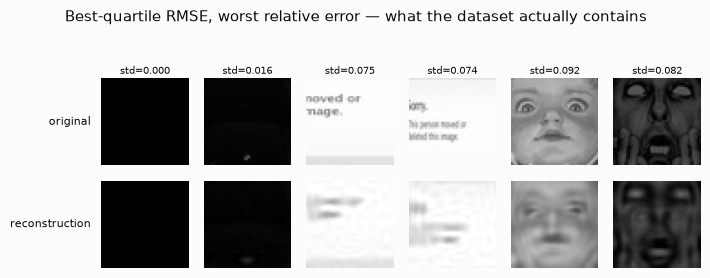

images with EXACTLY zero pixel variance (uniform blanks): 12
  ...and they still carry emotion labels: {'angry': 8, 'happy': 1, 'sad': 1, 'surprise': 1, 'neutral': 1}

near-white low-detail images (scraper placeholder pages): 48
  labels: {'angry': 4, 'disgust': 5, 'fear': 7, 'happy': 11, 'sad': 6, 'surprise': 9, 'neutral': 6}

1 of them is in the validation fold, and 100% of the real validation
faces reconstruct WORSE -> a low RMSE is not evidence of a good sample.


In [30]:
rel_err = recon_err_valid / np.maximum(X_valid.std(axis=1), 1e-6)
best_quartile = np.flatnonzero(recon_err_valid <= np.quantile(recon_err_valid, 0.25))
worst_relative = best_quartile[np.argsort(-rel_err[best_quartile])][:6]

fig, axes = plt.subplots(2, 6, figsize=(7.2, 2.7))
for col, idx in enumerate(worst_relative):
    show_face(axes[0, col], X_valid[idx],
              f"std={X_valid[idx].std():.3f}")
    show_face(axes[1, col], recon_valid[idx].clip(0, 1))
axes[0, 0].text(-0.12, 0.5, "original", transform=axes[0, 0].transAxes,
                ha="right", va="center", fontsize=8, color=INK)
axes[1, 0].text(-0.12, 0.5, "reconstruction", transform=axes[1, 0].transAxes,
                ha="right", va="center", fontsize=8, color=INK)
fig.suptitle("Best-quartile RMSE, worst relative error — what the dataset actually contains",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

pixel_std = X.std(axis=1)
blank = pixel_std == 0
print(f"images with EXACTLY zero pixel variance (uniform blanks): {blank.sum()}")
print("  ...and they still carry emotion labels:",
      {label_names[i]: int(c) for i, c in enumerate(np.bincount(y[blank], minlength=7)) if c})
near_blank = (pixel_std < 0.13) & (X.mean(axis=1) > 0.85)
print(f"\nnear-white low-detail images (scraper placeholder pages): {near_blank.sum()}")
print("  labels:", {label_names[i]: int(c) for i, c in enumerate(np.bincount(y[near_blank], minlength=7)) if c})
blank_valid = blank[is_valid]
if blank_valid.any():
    worse = np.mean([(recon_err_valid > e).mean() for e in recon_err_valid[blank_valid]])
    n = int(blank_valid.sum())
    subject = f"{n} of them is" if n == 1 else f"{n} of them are"
    print(f"\n{subject} in the validation fold, and {100 * worse:.0f}% of the real validation"
          f"\nfaces reconstruct WORSE -> a low RMSE is not evidence of a good sample.")

**FER-2013 contains images that are not faces at all.** Four of the six panels above are
not photographs of people: two are (near-)uniformly black frames, and two are screenshots
of a web page reading *"This person moved or deleted this image."* — placeholder pages the
original scraper saved and never filtered out. They still carry emotion labels.

Counted across the whole dataset: **12 images have exactly zero pixel variance** — flat,
featureless rectangles — and they are labelled `angry` (8), `happy`, `sad`, `surprise` and
`neutral`. Another ~48 are near-white low-detail placeholder pages, spread across all seven
classes.

Two consequences, both relevant to this notebook:

1. **Reconstruction error is a bad quality filter.** These images sit in the *best* RMSE
   quartile — a constant image is trivially representable by the mean face plus a PC1
   offset. Any pipeline that trusts "low reconstruction error = good sample" will happily
   promote garbage. Relative error catches them immediately, which is why the audit was
   worth doing.
2. **They contaminate the class means, but negligibly.** A dozen blanks against 7 215
   happy and 4 830 sad training faces shifts $d$ by a fraction of a percent. The real
   damage from FER-2013's data quality is the ordinary label noise discussed above, not
   these outliers — but their existence is a fair warning about how the labels were
   produced.

## 8. Would NMF work as the compressor?

PCA is not the only invertible factorisation. **NMF** decomposes $X \approx W H$ with both
factors non-negative, which for images is an appealing prior: it cannot use "negative
light", so its components tend to be **localised parts** rather than global patterns.
Since the decoder $\hat{x} = wH$ is again just a matrix product, NMF is invertible and the
same arithmetic is available.

We fit it on a random 8 000-face subsample of the training fold with 64 components (NMF is
an iterative non-convex optimisation, far more expensive than an eigendecomposition — the
`ConvergenceWarning` below is expected and honest: we cap it at 200 iterations and it has
not converged, whereas PCA's eigendecomposition has no such knob to get wrong). We compare
against **PCA truncated to the same 64 components** so the two have equal capacity, and we
score the morphs with the **pixel-space random forest** — the probe that does not care
which basis produced the image, which is what makes the comparison fair.

In [31]:
nmf_idx = rng.choice(np.flatnonzero(is_train), 8000, replace=False)
N_NMF = 64
nmf, nmf_seconds = timed(lambda: NMF(n_components=N_NMF, init="nndsvda", max_iter=200,
                                     random_state=RANDOM_STATE).fit(X[nmf_idx]))
W_nmf_train = nmf.transform(X[nmf_idx])
W_nmf_valid = nmf.transform(X_valid)
print(f"NMF({N_NMF}) fitted on {len(nmf_idx)} faces in {nmf_seconds:.1f}s "
      f"({nmf.n_iter_} iterations)")

pca_64 = truncate_pca(pca_full, N_NMF)
rmse_pca64 = float(np.sqrt(((pca_64.inverse_transform(pca_64.transform(X_valid)) - X_valid) ** 2).mean()))
rmse_nmf = float(np.sqrt(((W_nmf_valid @ nmf.components_ - X_valid) ** 2).mean()))
print(f"\nheld-out RMSE at {N_NMF} components:  PCA {rmse_pca64:.4f}   NMF {rmse_nmf:.4f}")
print(f"(PCA at K={K}: {recon_table.loc[K, 'valid RMSE']:.4f})")
print("PCA is optimal in this metric by Eckart-Young; NMF pays for the non-negativity constraint.")

/home/ibroximjon/Projects/School-21/ML6_Unsupervised_learning_ID_1254805-1/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


/home/ibroximjon/Projects/School-21/ML6_Unsupervised_learning_ID_1254805-1/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NMF(64) fitted on 8000 faces in 16.9s (200 iterations)



held-out RMSE at 64 components:  PCA 0.0918   NMF 0.0963
(PCA at K=200: 0.0626)
PCA is optimal in this metric by Eckart-Young; NMF pays for the non-negativity constraint.


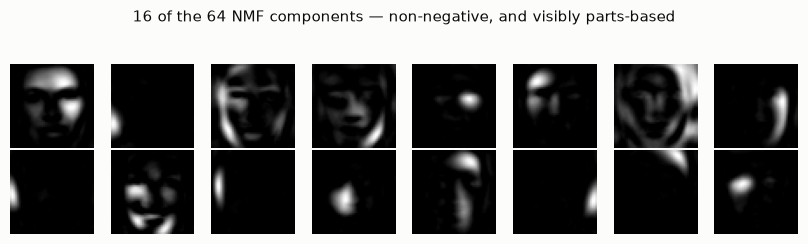

In [32]:
fig, axes = plt.subplots(2, 8, figsize=(8.2, 2.3))
for i, ax in enumerate(axes.ravel()):
    show_face(ax, nmf.components_[i], vmin=0, vmax=float(nmf.components_[i].max()))
fig.suptitle("16 of the 64 NMF components — non-negative, and visibly parts-based",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

In [33]:
y_nmf = y[nmf_idx]
d_nmf = W_nmf_train[y_nmf == HAPPY].mean(axis=0) - W_nmf_train[y_nmf == SAD].mean(axis=0)
print(f"d_nmf: {(d_nmf < 0).mean():.1%} of its coordinates are negative "
      "-> 'becoming happy' requires switching some parts OFF")

W_sad_valid = W_nmf_valid[y_valid == SAD]

# Equal-capacity PCA baseline: same 64 components, same recipe for the direction.
Z64_train = pca_64.transform(X_train)
Z64_sad_valid = pca_64.transform(X_valid[y_valid == SAD])
d_64 = Z64_train[y_train == HAPPY].mean(axis=0) - Z64_train[y_train == SAD].mean(axis=0)

forest = probes["RandomForest (pixels)"]
rows = []
for a in [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]:
    W_morph = np.clip(W_sad_valid + a * d_nmf, 0, None)     # non-negativity is enforced
    rows.append({
        "alpha": a,
        "NMF: % coords clipped to 0": 100 * float((W_sad_valid + a * d_nmf < 0).mean()),
        "NMF(64) P(happy)": float(forest.predict_proba(
            (W_morph @ nmf.components_).clip(0, 1))[:, 1].mean()),
        "PCA(64) P(happy)": float(forest.predict_proba(
            pca_64.inverse_transform(Z64_sad_valid + a * d_64).clip(0, 1))[:, 1].mean()),
        f"PCA({K}) P(happy)": float(forest.predict_proba(
            pca.inverse_transform(Z_sad_valid + a * d).clip(0, 1))[:, 1].mean()),
    })
nmf_table = pd.DataFrame(rows).set_index("alpha")
nmf_table.round(3)

d_nmf: 10.9% of its coordinates are negative -> 'becoming happy' requires switching some parts OFF


,NMF: % coords clipped to 0,NMF(64) P(happy),PCA(64) P(happy),PCA(200) P(happy)
alpha,,,,
0.0,0.000,0.513,0.508,0.495
0.5,1.037,0.577,0.570,0.550
1.0,1.091,0.639,0.632,0.606
1.5,1.134,0.693,0.685,0.654
2.0,1.205,0.737,0.726,0.695
3.0,1.352,0.793,0.781,0.750


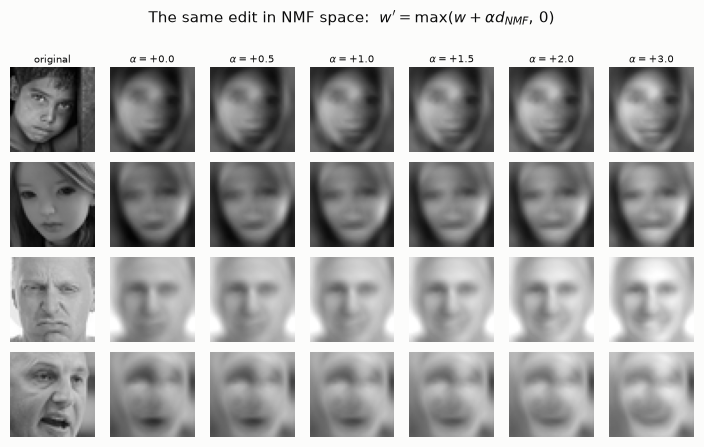

In [34]:
nmf_examples = pick_faces(SAD, 4, generator=np.random.default_rng(RANDOM_STATE + 2))
alphas_nmf = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
fig, axes = plt.subplots(len(nmf_examples), len(alphas_nmf) + 1,
                         figsize=(1.02 * (len(alphas_nmf) + 1), 1.02 * len(nmf_examples) + 0.35))
valid_pos = {int(v): i for i, v in enumerate(np.flatnonzero(y_valid == SAD))}
for row, idx in enumerate(nmf_examples):
    show_face(axes[row, 0], X_valid[idx], "original" if row == 0 else None)
    for col, a in enumerate(alphas_nmf):
        w = np.clip(W_nmf_valid[idx] + a * d_nmf, 0, None)
        show_face(axes[row, col + 1], (w @ nmf.components_).clip(0, 1),
                  f"$\\alpha={a:+.1f}$" if row == 0 else None)
fig.suptitle("The same edit in NMF space:  $w' = \\max(w + \\alpha d_{NMF},\\, 0)$",
             fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

**NMF verdict: it works, and — contrary to what one might expect — it is not worse.**

*Reconstruction.* At an equal 64 components, held-out RMSE is **0.0963 (NMF)** against
**0.0918 (PCA)**: NMF pays about **5 % more error** for its constraint. That is the
expected ordering — Eckart–Young guarantees no rank-64 approximation can beat PCA in
squared error, and NMF carries the extra non-negativity restriction on top. What it buys
for the price is **interpretability**: the component grid is unmistakably *parts-based* —
bright localised blobs on a black field (a cheek, a chin and mouth region, one side of the
face, a forehead patch) rather than PCA's global light/dark standing waves. Lee & Seung's
"parts of objects" claim is visible at a glance.

*Editing.* The morph works, and on the shared pixel-space probe it is **marginally
stronger** than the equal-capacity PCA morph: $P(\text{happy})$ over
$\alpha = 0 \to 1 \to 2$ goes **0.513 → 0.639 → 0.737** for NMF(64) against
**0.508 → 0.632 → 0.726** for PCA(64). The prior expectation — that non-negativity would
cripple the arithmetic — turns out to be **too pessimistic at this rank**, and the table
says why: only **10.9 %** of $d_{\text{NMF}}$'s coordinates are negative, and clipping
$w + \alpha d_{\text{NMF}}$ at zero touches just **1.1 %** of coordinates at $\alpha = 1$,
rising only to 1.4 % at $\alpha = 3$. The constraint is barely binding, so the edit behaves
almost like an unconstrained translation. The mechanism is still real — components cannot
cancel, so "remove the frown" has to be expressed as "turn some parts down", and it *will*
saturate once clipping becomes common — it simply does not bite in this regime.

*The trap in that comparison.* Notice that **PCA(64) also beats PCA(200)** on the probe
(0.508 → 0.632 → 0.726 versus 0.495 → 0.606 → 0.695), and that the 64-component models
already start higher at $\alpha = 0$. A coarser basis does not produce a *better* edit; it
produces a **blurrier, more prototypical** face, and a prototype is easier for a
classifier to file under "happy". This is a warning about the metric, not a result about
the method: probe score alone rewards averaging, so it must be read next to the
reconstruction error and the strips, where the 200-component PCA is visibly the one that
keeps the person recognisable.

The general lesson stands, just more narrowly than the textbook version: a good
*reconstruction* basis is not automatically a good *editing* basis, and the property the
whole task actually depends on is **invertibility plus a decoder that accepts points the
data never produced**. PCA gives that unconditionally; NMF gives it subject to a
constraint that happens to be slack here and would not be at higher $\alpha$ or higher
rank.

## Conclusions

**The task, answered.** A PCA with **$K = 200$ components** compresses each 48×48 face
from 2304 numbers to 200 (**11.5×**) while retaining **93.9 %** of the training pixel
variance and reconstructing held-out faces to an RMSE of **0.063** (≈16 grey levels).
Inside that latent space the difference of the happy and sad class means,
$d = \bar{z}_H - \bar{z}_S$, is a **smile vector**: decoded on its own it is a bright band
across the mouth with shadowed corners, and adding $\alpha d$ to a sad face's code turns it
into a smiling face while preserving identity, pose and hair. Negative $\alpha$ runs the
edit backwards and removes a smile.

**Why it works.** Only because PCA is **invertible**. Any dimensionality reduction can put
happy and sad faces in different places; the point of this task is that we must be able to
*come back*, and `inverse_transform` is an exact linear formula that decodes any point of
the latent space — including points we invented. t-SNE has no inverse; UMAP's is a second
learned approximation. Linearity is what makes the arithmetic itself meaningful: a
translation in $z$ leaves every component of the face orthogonal to $d$ untouched.

**The evidence, not the claim.** Three probe classifiers trained on the training fold and
applied to morphed **validation** faces all report strictly monotone movement across the
expression axis, over all eleven steps of the $\alpha$ grid, in both directions. The most
convincing is the random forest that works on **raw pixels of the decoded image** and has
never seen the latent space: on 1 247 held-out sad faces it goes
$P(\text{happy}) = 0.495 \to 0.606 \to 0.695$ for $\alpha = 0 \to 1 \to 2$. The non-linear
MLP probe, for which monotonicity is in no way guaranteed, gives
$0.400 \to 0.607 \to 0.788$. Rescaled onto each probe's own real-sad → real-happy
interval, $\alpha = 1$ covers **57–61 %** of the gap and $\alpha \approx 1.25$–2 covers all
of it. Running the same vector backwards on 1 774 held-out happy faces mirrors the effect
(MLP $0.737 \to 0.559 \to 0.370$).

**What is honestly wrong with it.**

* $d$ is a **population** effect (Cohen's $d = 0.38$): it reliably shifts a distribution,
  not every individual face. Some morphs are convincing smiles, some barely change.
* **51 % of $\|d\|^2$ is the global-brightness component** — happy photographs in
  FER-2013 are simply brighter. We showed this is a passenger and not the cause (PC1 alone
  moves $P(\text{happy})$ by only 0.014; removing PC1 costs 0.008), and `d_no_pc1` is the
  cleaner direction to use.
* The faces are **unregistered** 48×48 crops, so $d$ is an average over misaligned mouths;
  it works on roughly frontal faces and smears on profiles. Aligning the dataset first is
  the single highest-value improvement available.
* Beyond $|\alpha| \approx 2$ the code leaves the data manifold — clipped pixels rise from
  1.5 % at $\alpha = 0$ to 4.0 % at $\alpha = 3$ and 21.5 % at $\alpha = 8$, producing
  blown-out patches and inverted eye and mouth sockets.
* Outputs are inherently **blurry**: a morph can be no sharper than a 200-component
  reconstruction — and low squared error does not guarantee a recognisable person, as the
  bald-man reconstruction in section 7 shows.
* The probe score on its own is a **misleading** target: coarser bases (PCA-64, NMF-64)
  score *higher* than PCA-200 simply because their output is closer to a generic
  prototype. Reconstruction fidelity and the visual strips have to be read alongside it.
* And so is reconstruction error: the audit in section 7 turned up **12 images with
  exactly zero pixel variance** and ~48 scraper placeholder pages inside FER-2013, all
  carrying emotion labels, all sitting comfortably in the *best* RMSE quartile.

**And a methodological note.** Section 5's first probe is a linear model, for which a
monotone response to a linear edit is guaranteed by algebra rather than earned by the
method. Recognising that is why the non-linear and basis-independent probes are in the
notebook at all — a validation that cannot fail is not a validation.

In [35]:
print(f"total notebook runtime: {(time.perf_counter() - NB_START) / 60:.1f} min")

total notebook runtime: 1.6 min
